# Forex Data Exploration
Pag-aaral ng price data mula sa MetaTrader 5

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from datetime import datetime
import warnings
warnings.filterwarnings('ignore')

plt.style.use('ggplot')
%matplotlib inline

print('Libraries loaded successfully')

Libraries loaded successfully


## 1. Connect sa MT5 at mag-fetch ng data

In [2]:
import os
from dotenv import load_dotenv
load_dotenv()

import MetaTrader5 as mt5

if not mt5.initialize():
    print("MT5 initialize failed")
else:
    print("MT5 initialized")

    # Login with credentials
    login = int(os.getenv("MT5_LOGIN", "0"))
    password = os.getenv("MT5_PASSWORD")
    server = os.getenv("MT5_SERVER", "").strip()

    if login and password and server:
        authorized = mt5.login(login, password=password, server=server)
        if authorized:
            acc_info = mt5.account_info()
            if acc_info:
                print(f"Account: {acc_info.login} @ {acc_info.server}")
                print(f"Balance: ${acc_info.balance:.2f}")
                print(f"Equity: ${acc_info.equity:.2f}")
        else:
            print(f"Login failed (error: {mt5.last_error()})")
    else:
        acc_info = mt5.account_info()
        if acc_info:
            print(f"Already logged in: {acc_info.login} @ {acc_info.server}")
            print(f"Balance: ${acc_info.balance:.2f}")
        else:
            print("No credentials - using anonymous access")

MT5 initialized
Account: 11210667 @ VantageMarkets-Demo
Balance: $4654.85
Equity: $4654.85


In [3]:
# Kunin natin iba't ibang timeframe
symbol = "EURUSD"
timeframes = {
    'M5': mt5.TIMEFRAME_M5,
    'H1': mt5.TIMEFRAME_H1,
    'H4': mt5.TIMEFRAME_H4,
    'D1': mt5.TIMEFRAME_D1,
}

# Bar counts para roughly 1 year per timeframe
bar_counts = {'M5': 25000, 'H1': 5000, 'H4': 1500, 'D1': 365}
data = {}
for name, tf in timeframes.items():
    n = bar_counts[name]
    r = mt5.copy_rates_from_pos(symbol, tf, 0, n)
    if r is not None:
        d = pd.DataFrame(r)
        d['time'] = pd.to_datetime(d['time'], unit='s')
        data[name] = d.set_index('time')
        print(f"{name}: {len(d)} bars ({d['time'].iloc[0]} to {d['time'].iloc[-1]})")
    else:
        print(f"{name}: No data")

M5: 25000 bars (2026-01-29 04:20:00 to 2026-05-29 23:55:00)
H1: 5000 bars (2025-08-08 16:00:00 to 2026-05-29 23:00:00)
H4: 1500 bars (2025-06-12 00:00:00 to 2026-05-29 20:00:00)
D1: 365 bars (2025-01-02 00:00:00 to 2026-05-29 00:00:00)


## 2. Price Chart Visualization

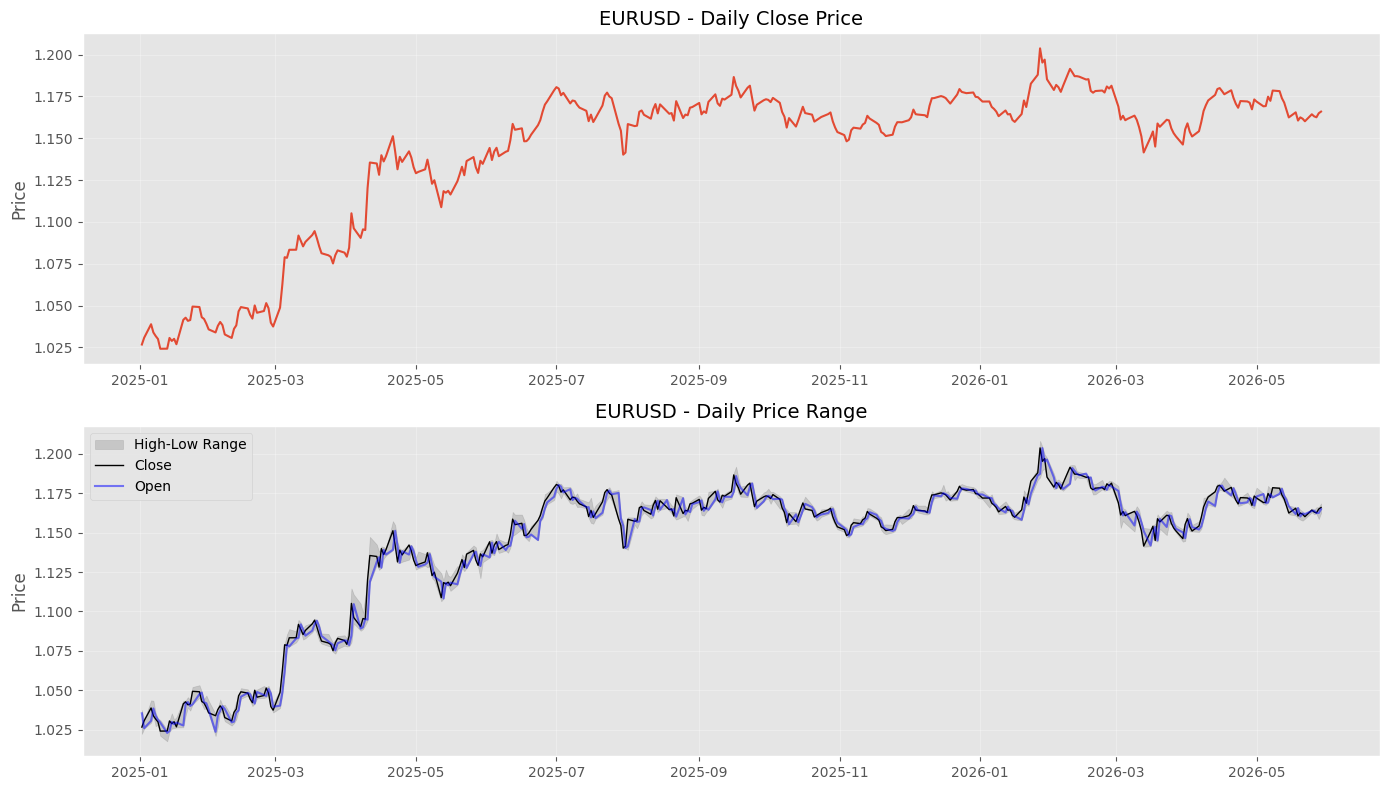

In [4]:
fig, axes = plt.subplots(2, 1, figsize=(14, 8))

# Daily close price
axes[0].plot(data['D1'].index, data['D1']['close'], linewidth=1.5)
axes[0].set_title(f'{symbol} - Daily Close Price', fontsize=14)
axes[0].set_ylabel('Price')
axes[0].grid(True, alpha=0.3)

# Candlestick-like (high/low range)
axes[1].fill_between(data['D1'].index, data['D1']['low'], data['D1']['high'], 
                      alpha=0.3, color='gray', label='High-Low Range')
axes[1].plot(data['D1'].index, data['D1']['close'], color='black', linewidth=1, label='Close')
axes[1].plot(data['D1'].index, data['D1']['open'], color='blue', alpha=0.5, label='Open')
axes[1].set_title(f'{symbol} - Daily Price Range', fontsize=14)
axes[1].set_ylabel('Price')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

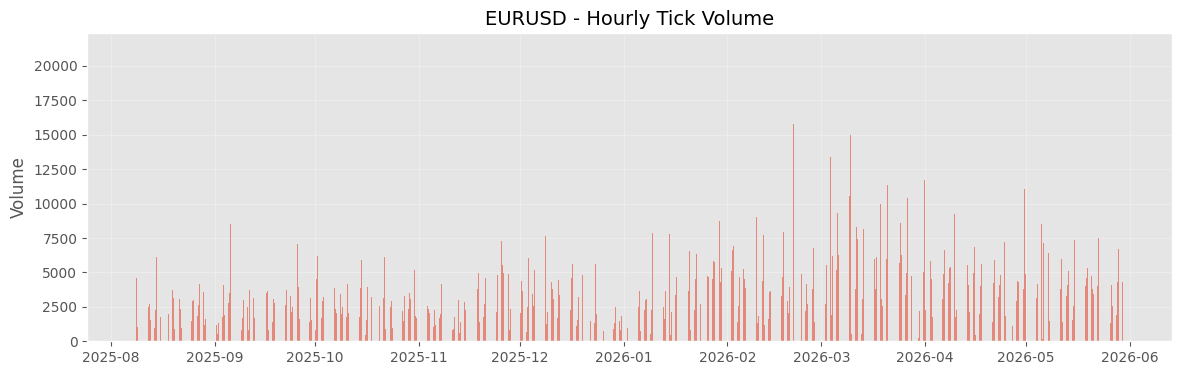

In [5]:
# Volume analysis
fig, ax = plt.subplots(figsize=(14, 4))
ax.bar(data['H1'].index, data['H1']['tick_volume'], width=0.02, alpha=0.6)
ax.set_title(f'{symbol} - Hourly Tick Volume', fontsize=14)
ax.set_ylabel('Volume')
ax.grid(True, alpha=0.3)
plt.show()

## 3. Technical Indicators

In [6]:
df_h1 = data['H1'].copy()

# Moving Averages
df_h1['sma_20'] = df_h1['close'].rolling(20).mean()
df_h1['sma_50'] = df_h1['close'].rolling(50).mean()
df_h1['ema_12'] = df_h1['close'].ewm(span=12, adjust=False).mean()
df_h1['ema_26'] = df_h1['close'].ewm(span=26, adjust=False).mean()

# RSI
delta = df_h1['close'].diff()
gain = delta.clip(lower=0)
loss = -delta.clip(upper=0)
avg_gain = gain.ewm(span=14, adjust=False).mean()
avg_loss = loss.ewm(span=14, adjust=False).mean()
rs = avg_gain / avg_loss.replace(0, np.nan)
df_h1['rsi'] = 100 - (100 / (1 + rs))

# MACD
ema12 = df_h1['close'].ewm(span=12, adjust=False).mean()
ema26 = df_h1['close'].ewm(span=26, adjust=False).mean()
df_h1['macd'] = ema12 - ema26
df_h1['macd_signal'] = df_h1['macd'].ewm(span=9, adjust=False).mean()
df_h1['macd_hist'] = df_h1['macd'] - df_h1['macd_signal']

# Bollinger Bands
df_h1['bb_middle'] = df_h1['close'].rolling(20).mean()
bb_std = df_h1['close'].rolling(20).std()
df_h1['bb_upper'] = df_h1['bb_middle'] + (2 * bb_std)
df_h1['bb_lower'] = df_h1['bb_middle'] - (2 * bb_std)

# ATR
high_low = df_h1['high'] - df_h1['low']
high_close = (df_h1['high'] - df_h1['close'].shift()).abs()
low_close = (df_h1['low'] - df_h1['close'].shift()).abs()
tr = pd.concat([high_low, high_close, low_close], axis=1).max(axis=1)
df_h1['atr'] = tr.rolling(14).mean()

print("Indicators calculated:")
print(df_h1[['close', 'sma_20', 'sma_50', 'rsi', 'macd', 'atr']].tail())

Indicators calculated:
                       close    sma_20    sma_50        rsi      macd  \
time                                                                    
2026-05-29 19:00:00  1.16714  1.164842  1.163411  68.466217  0.000787   
2026-05-29 20:00:00  1.16619  1.164906  1.163476  57.248067  0.000784   
2026-05-29 21:00:00  1.16637  1.164976  1.163540  58.726537  0.000786   
2026-05-29 22:00:00  1.16641  1.165036  1.163615  59.089305  0.000783   
2026-05-29 23:00:00  1.16589  1.165091  1.163675  52.206380  0.000729   

                          atr  
time                           
2026-05-29 19:00:00  0.001270  
2026-05-29 20:00:00  0.001286  
2026-05-29 21:00:00  0.001309  
2026-05-29 22:00:00  0.001311  
2026-05-29 23:00:00  0.001273  


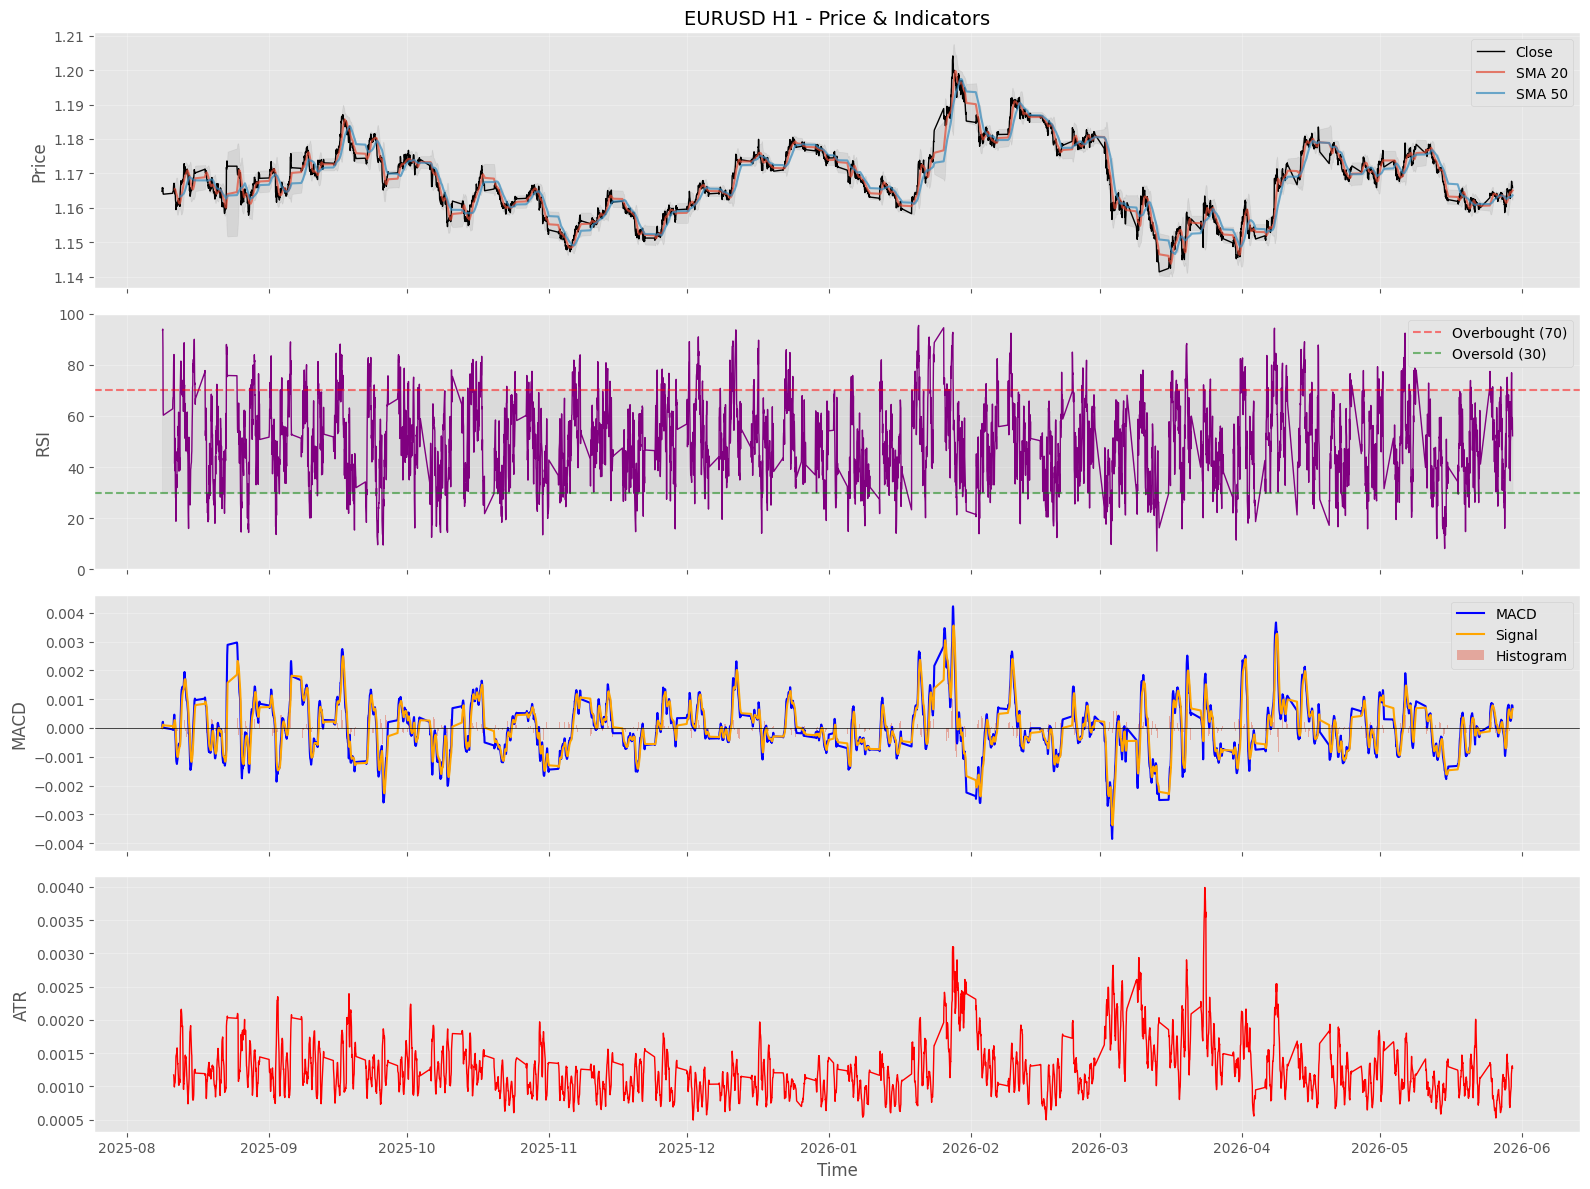

In [7]:
# Plot everything
fig, axes = plt.subplots(4, 1, figsize=(16, 12), sharex=True)

# Price + MAs + BB
ax = axes[0]
ax.plot(df_h1.index, df_h1['close'], label='Close', linewidth=1, color='black')
ax.plot(df_h1.index, df_h1['sma_20'], label='SMA 20', alpha=0.7)
ax.plot(df_h1.index, df_h1['sma_50'], label='SMA 50', alpha=0.7)
ax.fill_between(df_h1.index, df_h1['bb_upper'], df_h1['bb_lower'], alpha=0.15, color='gray')
ax.set_title(f'{symbol} H1 - Price & Indicators', fontsize=14)
ax.set_ylabel('Price')
ax.legend(loc='best')
ax.grid(True, alpha=0.3)

# RSI
ax = axes[1]
ax.plot(df_h1.index, df_h1['rsi'], color='purple', linewidth=1)
ax.axhline(y=70, color='red', linestyle='--', alpha=0.5, label='Overbought (70)')
ax.axhline(y=30, color='green', linestyle='--', alpha=0.5, label='Oversold (30)')
ax.fill_between(df_h1.index, 30, 70, alpha=0.1, color='gray')
ax.set_ylabel('RSI')
ax.set_ylim(0, 100)
ax.legend(loc='best')
ax.grid(True, alpha=0.3)

# MACD
ax = axes[2]
ax.plot(df_h1.index, df_h1['macd'], label='MACD', color='blue')
ax.plot(df_h1.index, df_h1['macd_signal'], label='Signal', color='orange')
ax.bar(df_h1.index, df_h1['macd_hist'], label='Histogram', alpha=0.4, width=0.02)
ax.axhline(y=0, color='black', linestyle='-', linewidth=0.5)
ax.set_ylabel('MACD')
ax.legend(loc='best')
ax.grid(True, alpha=0.3)

# ATR
ax = axes[3]
ax.plot(df_h1.index, df_h1['atr'], color='red', linewidth=1)
ax.set_ylabel('ATR')
ax.set_xlabel('Time')
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## 4. Multiple Forex Pairs Comparison

In [8]:
major_pairs = ['EURUSD', 'GBPUSD', 'USDJPY', 'USDCHF', 'AUDUSD', 'USDCAD', 'NZDUSD']
pair_data = {}

for pair in major_pairs:
    r = mt5.copy_rates_from_pos(pair, mt5.TIMEFRAME_D1, 0, 365)
    if r is not None:
        d = pd.DataFrame(r)
        d['time'] = pd.to_datetime(d['time'], unit='s')
        pair_data[pair] = d.set_index('time')
        print(f"{pair}: {len(d)} days loaded")
    else:
        print(f"{pair}: No data")

mt5.shutdown()

EURUSD: 365 days loaded
GBPUSD: 365 days loaded
USDJPY: 365 days loaded
USDCHF: 365 days loaded
AUDUSD: 365 days loaded
USDCAD: 365 days loaded
NZDUSD: 365 days loaded


True

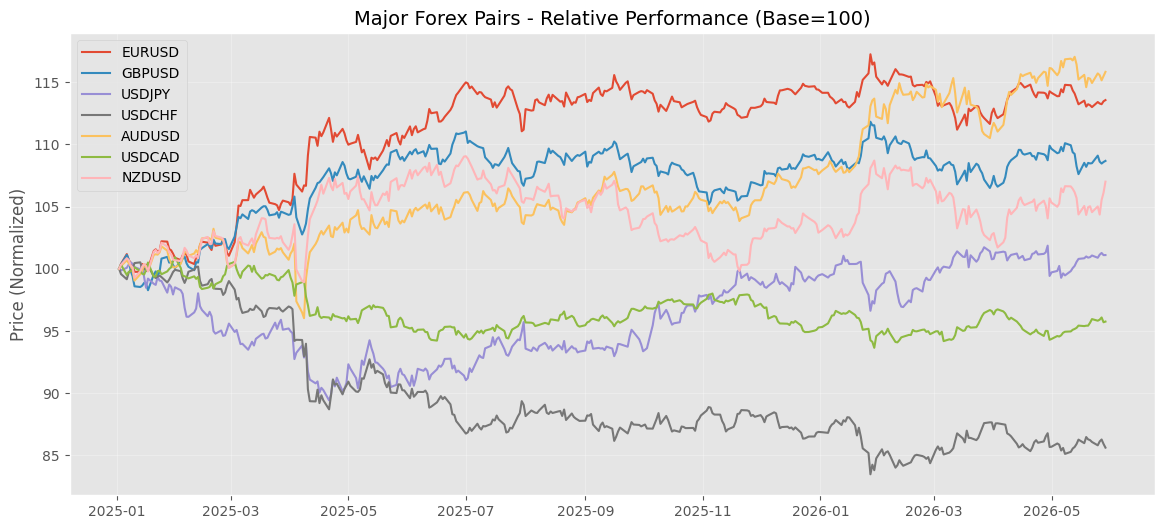

In [9]:
# Normalize prices to compare trends
fig, ax = plt.subplots(figsize=(14, 6))

for pair, d in pair_data.items():
    if len(d) > 0:
        normalized = d['close'] / d['close'].iloc[0] * 100
        ax.plot(d.index, normalized, label=pair, linewidth=1.5)

ax.set_title('Major Forex Pairs - Relative Performance (Base=100)', fontsize=14)
ax.set_ylabel('Price (Normalized)')
ax.legend(loc='best')
ax.grid(True, alpha=0.3)
plt.show()

In [10]:
# Correlation matrix
close_prices = pd.DataFrame({
    pair: d['close'] for pair, d in pair_data.items() if len(d) > 0
})

corr = close_prices.corr()
print("Correlation Matrix:")
corr.round(3)

Correlation Matrix:


,EURUSD,GBPUSD,USDJPY,USDCHF,AUDUSD,USDCAD,NZDUSD
EURUSD,1.000,0.942,0.064,-0.980,0.662,-0.864,0.609
GBPUSD,0.942,1.000,-0.123,-0.909,0.618,-0.899,0.777
USDJPY,0.064,-0.123,1.000,-0.171,0.580,0.016,-0.381
USDCHF,-0.980,-0.909,-0.171,1.000,-0.751,0.879,-0.585
AUDUSD,0.662,0.618,0.580,-0.751,1.000,-0.694,0.445
USDCAD,-0.864,-0.899,0.016,0.879,-0.694,1.000,-0.822
NZDUSD,0.609,0.777,-0.381,-0.585,0.445,-0.822,1.000


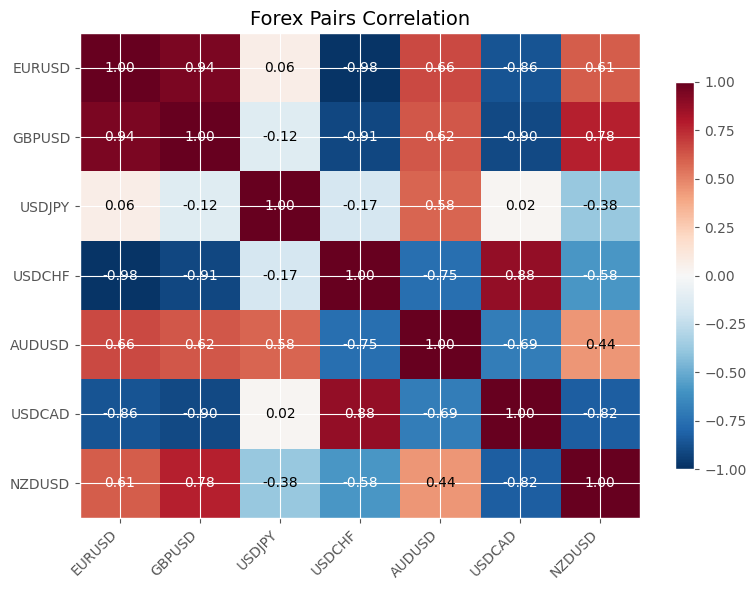

In [11]:
# Visualize correlation
import matplotlib.colors as mcolors

fig, ax = plt.subplots(figsize=(8, 6))
im = ax.imshow(corr, cmap='RdBu_r', vmin=-1, vmax=1, aspect='auto')

ax.set_xticks(range(len(corr.columns)))
ax.set_yticks(range(len(corr.columns)))
ax.set_xticklabels(corr.columns, rotation=45, ha='right')
ax.set_yticklabels(corr.columns)

for i in range(len(corr)):
    for j in range(len(corr)):
        ax.text(j, i, f'{corr.iloc[i, j]:.2f}', ha='center', va='center',
                color='white' if abs(corr.iloc[i, j]) > 0.5 else 'black')

ax.set_title('Forex Pairs Correlation', fontsize=14)
plt.colorbar(im, ax=ax, shrink=0.8)
plt.tight_layout()
plt.show()

## 5. Returns Analysis

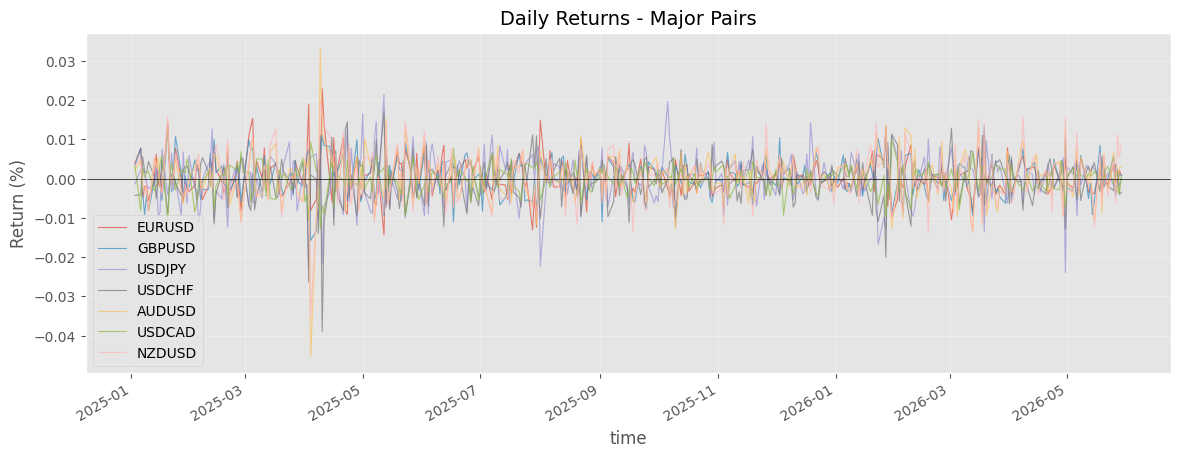

In [12]:
# Daily returns
daily_returns = close_prices.pct_change().dropna()

fig, ax = plt.subplots(figsize=(14, 5))
daily_returns.plot(ax=ax, alpha=0.7, linewidth=0.8)
ax.set_title('Daily Returns - Major Pairs', fontsize=14)
ax.set_ylabel('Return (%)')
ax.axhline(y=0, color='black', linestyle='-', linewidth=0.5)
ax.grid(True, alpha=0.3)
plt.show()

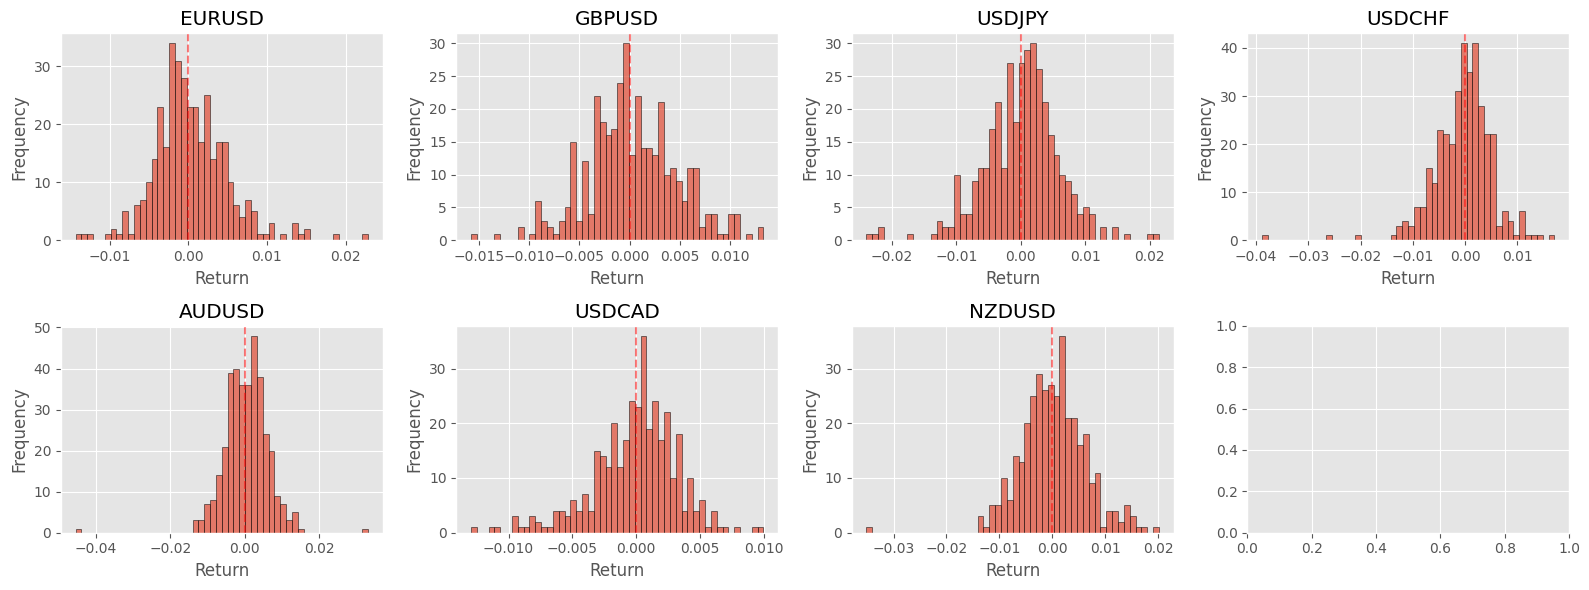

In [13]:
# Return distribution
fig, axes = plt.subplots(2, 4, figsize=(16, 6))
axes = axes.flatten()

for idx, (pair, returns) in enumerate(daily_returns.items()):
    if idx < len(axes):
        axes[idx].hist(returns, bins=50, alpha=0.7, edgecolor='black', linewidth=0.5)
        axes[idx].axvline(x=0, color='red', linestyle='--', alpha=0.5)
        axes[idx].set_title(f'{pair}')
        axes[idx].set_xlabel('Return')
        axes[idx].set_ylabel('Frequency')

plt.tight_layout()
plt.show()

In [14]:
# Summary statistics
stats = daily_returns.describe().T
stats['skew'] = daily_returns.skew()
stats['kurtosis'] = daily_returns.kurtosis()
stats['sharpe'] = daily_returns.mean() / daily_returns.std() * np.sqrt(252)
stats.round(4)

,count,mean,std,min,25%,50%,75%,max,skew,kurtosis,sharpe
EURUSD,364.0,0.0004,0.0047,-0.0143,-0.0024,-0.0002,0.0029,0.0228,0.7175,2.3746,1.2129
GBPUSD,364.0,0.0002,0.0045,-0.0158,-0.0027,-0.0003,0.0031,0.0133,0.0439,0.4026,0.8370
USDJPY,364.0,0.0000,0.0060,-0.0239,-0.0033,0.0005,0.0034,0.0214,-0.3904,2.0753,0.1276
USDCHF,364.0,-0.0004,0.0055,-0.0389,-0.0035,-0.0000,0.0028,0.0171,-1.2608,7.5383,-1.1816
AUDUSD,364.0,0.0004,0.0060,-0.0455,-0.0032,0.0006,0.0041,0.0332,-0.7524,10.7031,1.1139
USDCAD,364.0,-0.0001,0.0033,-0.0129,-0.0018,0.0003,0.0019,0.0100,-0.6235,1.3358,-0.5466
NZDUSD,364.0,0.0002,0.0062,-0.0351,-0.0037,0.0001,0.0038,0.0202,-0.1923,2.7496,0.5275


## 6. Key Takeaways

- **Price Action**: Trend behavior across timeframes
- **Indicator Signals**: RSI overbought/oversold levels, MACD crossovers
- **Pair Correlation**: Aling pairs ang magkakaugnay (e.g., EURUSD & USDCHF negative correlation)
- **Volatility**: ATR levels for stop loss/take profit placement
- **Return Distribution**: Normality check at risk assessment